In [1]:
%load_ext autoreload
%autoreload 2

import collections
import math
import numpy as np
import re
import scipy.stats
import tqdm
import torch
from torch import tensor, Tensor
from typing import Iterable, Any

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker
import pandas as pd
import seaborn as sns

import block_formats.experiments as E
import plot_utils
import data_utils as D

plot_utils.configure()

Recommend (Ubuntu):
  sudo apt-get install cm-super dvipng fonts-cmu texlive-latex-extra


In [ ]:
BASELINES = E.runs("20250506-results-baseline", progress=True)
WEIGHT_STATS = {r.config.model: r.summary.weight_stats for r in E.runs("20250423-weight-stats")}

RUNS_MAIN = E.runs("20250506-results-main", progress=True)
RUNS_FISHER = E.runs("20250506-results-fisher", progress=True)
RUNS_BLOCK_SIZE = E.runs("20250506-results-blocksize", progress=True)
RUNS_SCALE_MANTISSA = E.runs("20250506-results-scalemantissa", progress=True)
RUNS_SYMMETRY = E.runs("20250506-results-symmetry", progress=True)
RUNS_ELEMENT_FORMATS = E.runs("20250506-results-elementformats", progress=True)

query: 11it [00:00, 268.55it/s]
query: 4680it [00:28, 162.70it/s]
query: 1806it [00:10, 164.38it/s]
query: 165it [00:01, 132.47it/s]
query: 264it [00:01, 189.31it/s]
query: 198it [00:01, 143.27it/s]
query: 2442it [00:14, 171.76it/s]


In [4]:
RUNS = RUNS_MAIN + RUNS_FISHER + RUNS_BLOCK_SIZE + RUNS_SCALE_MANTISSA + RUNS_SYMMETRY + RUNS_ELEMENT_FORMATS

### Errors

In [12]:
list(run.error.cause.message for run in RUNS if run.meta.status == "failed")

["shape '[151936, 1, 3, 256]' is invalid for input of size 136134656",
 "shape '[151936, 1, 3, 256]' is invalid for input of size 136134656",
 "shape '[151936, 1, 3, 256]' is invalid for input of size 136134656",
 "shape '[262144, 1, 4, 256]' is invalid for input of size 301989888",
 "shape '[262144, 1, 4, 256]' is invalid for input of size 301989888",
 "shape '[262144, 1, 4, 256]' is invalid for input of size 301989888",
 'CUDA out of memory. Tried to allocate 2.00 GiB. GPU 0 has a total capacity of 79.25 GiB of which 604.75 MiB is free. Including non-PyTorch memory, this process has 78.65 GiB memory in use. Of the allocated memory 72.62 GiB is allocated by PyTorch, and 5.53 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)',
 'CUDA out of memory. Trie

## Main

In [ ]:
MODEL_GRID_ORDER = ["Llama-3.1-8B", "gemma-3-12b-pt", "phi-4",
                    "Llama-3.2-3B", "gemma-3-4b-pt", "Qwen2.5-7B",
                    "Llama-3.2-1B", "gemma-3-1b-pt", "Qwen2.5-3B"]


MODEL_FLAT_ORDER = ["Llama-3.1-8B", "phi-4", "gemma-3-12b-pt", "Qwen2.5-7B",
                    "gemma-3-4b-pt", "Llama-3.2-3B", "Qwen2.5-3B",
                    "Qwen2.5-1.5B", "Llama-3.2-1B", "gemma-3-1b-pt", "Qwen2.5-0.5B"]


def recalculate_bits_per_param(model: str, param_log: dict[str, Any]) -> float:
    # For Gemma, where the estimate in the logs includes the vision part
    # Note that this is approximate - it excludes layernorm parameters which aren't in weight_stats or param_log
    assert set(WEIGHT_STATS[model]) - {"multi_modal_projector.mm_input_projection_weight"} == set(param_log)
    return sum(param_log[k]["bits"] for k in param_log) / sum(math.prod(WEIGHT_STATS[model][k]["shape"]) for k in param_log)


def get_element_format_name(fmt: E.AttrDict) -> str:
    name = fmt.element_family
    if name == "fp" and "exponent_bits" in fmt.args:
        name = f"{name}-E{fmt.args.exponent_bits:.0f}"
    if name == "t" and "df" in fmt.args:
        name = f"{name}[{fmt.args.df:.0f}]"
    if fmt.compressor is not None:
        name = f"{name}+Z{fmt.compressor}"
    return name


def mean_and_stderr(name: str, data: list[float]) -> dict[str, float]:
    data = tensor(data)
    return {name: data.mean().item(),
            f"{name}_stderr": data.std().item() / len(data)**.5}


def get_rows() -> Iterable[dict[str, Any]]:
    for run in RUNS:
        test = run.config.test
        if run.meta.status == "finished":
            fmt = test.fmt
            bits_per_param = run.summary.bits_per_param
            if "gemma" in run.config.model:
                bits_per_param = recalculate_bits_per_param(run.config.model, run.summary.params)
            yield dict(
                # Config
                experiment=run.experiment.replace("20250506-results-", ""),
                model=run.config.model.split("/")[1],
                element_bits=fmt.element_bits,
                element_family=fmt.element_family,
                element_name=get_element_format_name(fmt),
                element_mode=fmt.args.get("mode", "default"),
                scaling=fmt.scaling,
                scaling_match=fmt.scaling_match,
                block={(None, None): "tensor", (1, None): "channel"}.get(tuple(fmt.block_shape), fmt.block_shape[1]),
                sparse_ratio=fmt.sparse_ratio,
                compression=fmt.compressor == "optimal",
                allocation=test.type.replace("quantise_", ""),
                error_weight=test.error_weight or "none",
                # Outcome
                **mean_and_stderr("kl_div", run.summary.kl_div),
                **mean_and_stderr("cross_entropy", run.summary.cross_entropy),
                bits_per_param=bits_per_param,
            )


df = pd.DataFrame.from_records(get_rows())
df["kl_div_efficiency"] = df.kl_div * 2**(2*df.bits_per_param)
df["kl_div_efficiency_stderr"] = df.kl_div_stderr * 2**(2*df.bits_per_param)

print("model:", list(df.model.unique()))
print("element_name:", list(df.element_name.unique()))
print("experiment:", list(df.experiment.unique()))
assert df.groupby(
    ["experiment", "model", "element_bits", "element_name", "element_mode", "scaling", "scaling_match", "block", "sparse_ratio", "allocation", "error_weight"]
).apply(len, include_groups=False).max() == 1

# Best over "element_mode"
dfb = D.best(df, "kl_div", ["experiment", "model", "element_bits", "element_name", "scaling", "scaling_match", "block", "sparse_ratio", "allocation", "error_weight"])

display(df.head())

model: ['Llama-3.1-8B', 'Llama-3.2-1B', 'Llama-3.2-3B', 'phi-4', 'Qwen2.5-0.5B', 'Qwen2.5-1.5B', 'Qwen2.5-3B', 'Qwen2.5-7B', 'gemma-3-1b-pt', 'gemma-3-4b-pt', 'gemma-3-12b-pt']
element_name: ['int+Zoptimal', 'int', 't', 'normal', 'laplace', 't[30]', 'lloyd_max', 'fp-E2']
experiment: ['main', 'fisher', 'blocksize', 'scalemantissa', 'symmetry', 'elementformats']


,experiment,model,element_bits,element_family,element_name,element_mode,scaling,scaling_match,block,sparse_ratio,compression,allocation,error_weight,kl_div,kl_div_stderr,cross_entropy,cross_entropy_stderr,bits_per_param,kl_div_efficiency,kl_div_efficiency_stderr
0,main,Llama-3.1-8B,3.0,int,int+Zoptimal,default,rms,search,64.0,0.000000,True,fixed,none,0.190885,0.003281,1.977858,0.018411,3.254851,17.393549,0.298957
1,main,Llama-3.1-8B,3.0,int,int+Zoptimal,default,rms,search,64.0,0.007812,True,fixed,none,0.183496,0.003172,1.970641,0.018329,3.630242,28.135272,0.486339
2,main,Llama-3.1-8B,3.0,int,int+Zoptimal,default,rms,search,channel,0.000000,True,fixed,none,0.197449,0.003325,1.984892,0.018422,3.000388,12.643543,0.212919
3,main,Llama-3.1-8B,3.0,int,int+Zoptimal,default,rms,search,channel,0.007812,True,fixed,none,0.175126,0.003084,1.961779,0.018403,3.374730,18.842598,0.331871
4,main,Llama-3.1-8B,3.0,int,int+Zoptimal,default,rms,search,channel,0.000977,True,fixed,none,0.178511,0.003273,1.965637,0.018308,3.056604,12.357307,0.226592


### `tradeoff_overview`

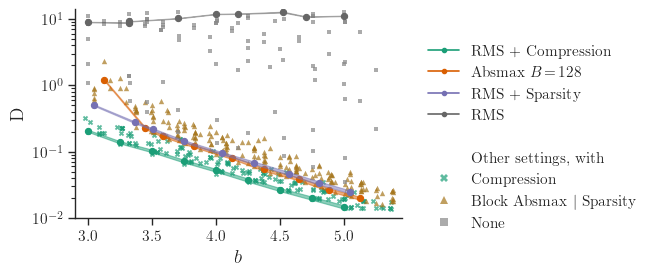

In [ ]:
tradeoff_lines = [
    (dict(element_name="int+Zoptimal", scaling="rms", block="tensor", sparse_ratio=0), dict(label="RMS + Compression", color=plot_utils.PALETTE[0])),
    (dict(element_name="t", scaling="absmax", block=128, sparse_ratio=0), dict(label=r"Absmax $B\!=\!128$", color=plot_utils.PALETTE[1])),
    (dict(element_name="t", scaling="rms", block="tensor", sparse_ratio=2**-10), dict(label="RMS + Sparsity", color=plot_utils.PALETTE[2])),
    (dict(element_name="t", scaling="rms", block="tensor", sparse_ratio=0), dict(label="RMS", color=plot_utils.PALETTE[7])),
]
tradeoff_d = (D.select(dfb, dict(experiment="main"))
    .pipe(lambda d: d[~((d.scaling == "rms") & (d.block != "tensor") & (d.sparse_ratio != 0))])
    .pipe(lambda d: d.assign(block_absmax=((~d.block.isin(["tensor", "channel"])) & (d.scaling == "absmax"))))
)

def tradeoff_overview(model: str, y: str, ax: matplotlib.axes.Axes) -> Any:
    d = tradeoff_d[tradeoff_d.model == model]
    points = [
        (d.compression, dict(color=plot_utils.PALETTE[0], marker="X", s=15, label="Compression")),
        (~d.compression & (d.block_absmax | d.sparse_ratio), dict(color=plot_utils.PALETTE[6], marker="^", s=15, label="Block Absmax $|$ Sparsity")),
        (~(d.compression | d.block_absmax | d.sparse_ratio), dict(color="#888", marker="s", s=10, label="None")),
    ]

    for select, args in tradeoff_lines:
        g = D.select(d, select)
        ax.fill_between(g.bits_per_param, g[y] - 2*g[f"{y}_stderr"], g[y] + 2*g[f"{y}_stderr"], **args, alpha=.5)
        ax.scatter(g.bits_per_param, g[y], **args, s=20)

    for filter, args in points:
        d[filter].pipe(lambda g: ax.scatter(g.bits_per_param, g[y], **args, zorder=-1, alpha=.7, lw=0))

    ax.set_yscale("log")
    ax.set_xlabel("$b$")
    ax.set_ylabel(dict(kl_div=r"$\mathrm{D}$", kl_div_efficiency=r"$\mathrm{D} \cdot 2^{2 b}$")[y])
    return [
        [(dict(**d, marker="o"),) for _, d in tradeoff_lines],
        "Other settings, with",
        [(_, dict(**D.drop(d, "s"), lw=0, ms=6, alpha=.7, mew=0)) for _, d in points],
    ]

_, ax = plt.subplots(figsize=(6.5, 3))
build = tradeoff_overview("Llama-3.1-8B", "kl_div", ax)
plot_utils.set_figure_legend(ax.figure, build=build)
ax.set_ylim((10**-2, 14))
ax.set_xlim((2.9, 5.45))
plot_utils.tidy(ax.figure)
plot_utils.save("tradeoff_overview_llama8b")

remote: Updating references: 100% (1/1)           


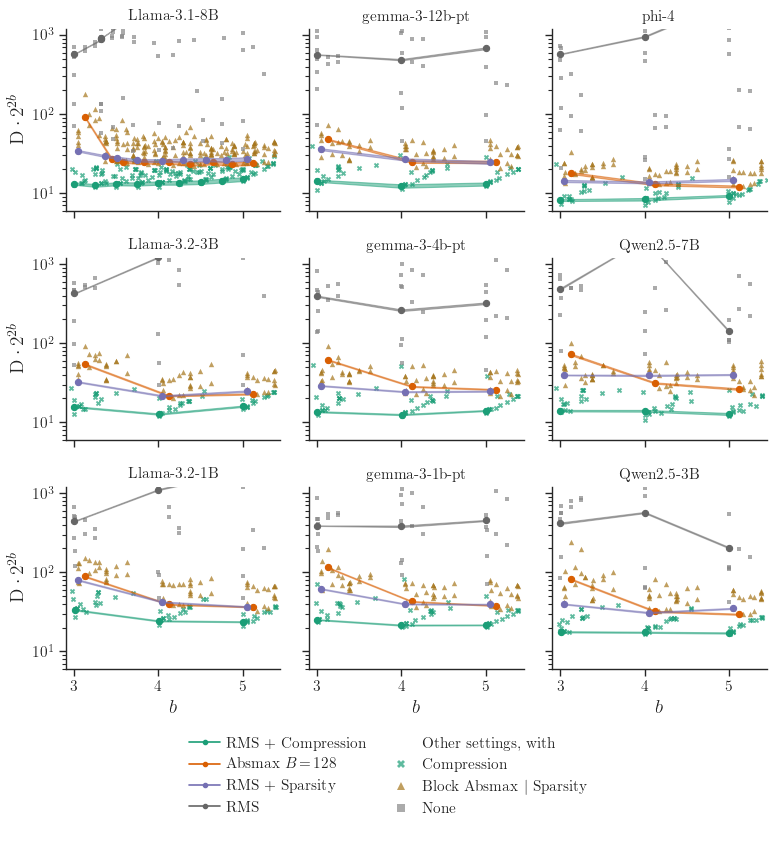

In [ ]:
figw, figh = matplotlib.rcParams["figure.figsize"]
_, axs = plt.subplots(nrows=3, ncols=3, figsize=(figw, 2.5 * figh), sharey=True, sharex=True)

for model, ax in zip(MODEL_GRID_ORDER, axs.flatten()):
    if model is None:
        ax.remove()
        continue
    build = tradeoff_overview(model, "kl_div_efficiency", ax)
    ax.set_title(model)

for ax in axs[:, 1:].flatten():
    ax.set_ylabel("")
for ax in axs[:-1, :].flatten():
    ax.set_xlabel("")

axs[0, 0].set_ylim((6e0, 1.2e3))
axs[0, 0].set_xlim((2.9, 5.45))
plot_utils.set_figure_legend(
    axs[0, 0].figure, build=build,
    bbox_to_anchor=(0.0, 0.02, 1.0, 0), loc="upper center", ncols=2, columnspacing=1.25, handletextpad=0.4
)

plot_utils.tidy(axs[0, 0].figure)
plot_utils.save("tradeoff_overview_grid")

### `TODO`

Text(0, 0.5, '$\\mathrm{D}$')

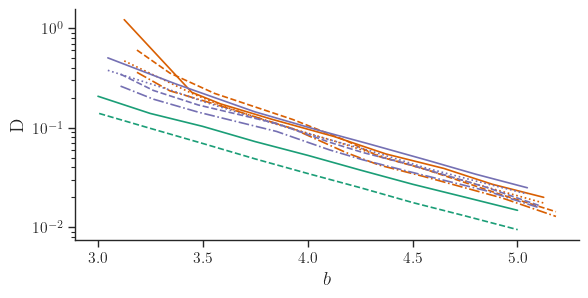

In [ ]:
# TODO
d = (D.select(dfb, dict(model="Llama-3.1-8B", element_name=["int", "t", "int+Zoptimal"]))
    .pipe(lambda d: d[(d.experiment == "fisher") | (d.experiment == "main")])
    .pipe(lambda d: d[~((d.scaling == "rms") & d.sparsity & (d.block != "tensor"))])
    .pipe(lambda d: d.assign(block_absmax=((~d.block.isin(["tensor", "channel"])) & (d.scaling == "absmax"))))
)

lines = [
    (dict(element_name="int+Zoptimal", scaling="rms", block="tensor", sparsity=False), dict(label="RMS + Compression", color=plot_utils.PALETTE[0])),
    (dict(element_name="t", scaling="absmax", block=128, sparsity=False), dict(label=r"Absmax $B\!=\!128$", color=plot_utils.PALETTE[1])),
    (dict(element_name="t", scaling="rms", block="tensor", sparsity=True), dict(label="RMS + Sparsity", color=plot_utils.PALETTE[2])),
]

_, ax = plt.subplots(figsize=(6.5, 3))
for select, args in lines:
    g = D.select(d, select)
    for gg, style in zip([g[(g.allocation == "fixed") & (g.error_weight == "none")],
                          g[(g.allocation == "variable") & (g.error_weight == "none")],
                          g[(g.allocation == "fixed") & (g.error_weight == "fisher")],
                          g[(g.allocation == "variable") & (g.error_weight == "fisher")],
                          ], ["-", "--", ":", "-."]):
        ax.plot(gg.bits_per_param, gg.kl_div, **args, ls=style)

ax.set_yscale("log")
# ax.set_ylim((8e-3, 1))
ax.set_xlabel("$b$")
ax.set_ylabel(r"$\mathrm{D}$")

## Detail

### `kl_vs_cross_entropy`

In [22]:
baseline_cross_entropy = {
    run.config.model: tensor(run.summary.cross_entropy).mean().item()
    for run in E.runs("20250506-results-baseline")
}

In [23]:
def get_rows() -> Iterable[dict[str, Any]]:
    model = "meta-llama/Llama-3.1-8B"
    for run in RUNS:
        if run.config.model == model and run.experiment == "20250506-results-main":
            kl_div_mean = tensor(run.summary.kl_div).mean().item()
            cross_entropy_delta_mean = tensor(run.summary.cross_entropy).mean().item() - baseline_cross_entropy[model]
            yield from (
                dict(kl_div_mean=kl_div_mean, cross_entropy_delta_mean=cross_entropy_delta_mean,
                     metric="kl_div", sample=x)
                for x in run.summary.kl_div
            )
            yield from (
                dict(kl_div_mean=kl_div_mean, cross_entropy_delta_mean=cross_entropy_delta_mean,
                     metric="cross_entropy_delta", sample=x - baseline_cross_entropy[model])
                for x in run.summary.cross_entropy
            )

df = pd.DataFrame.from_records(get_rows())

remote: Updating references: 100% (1/1)           


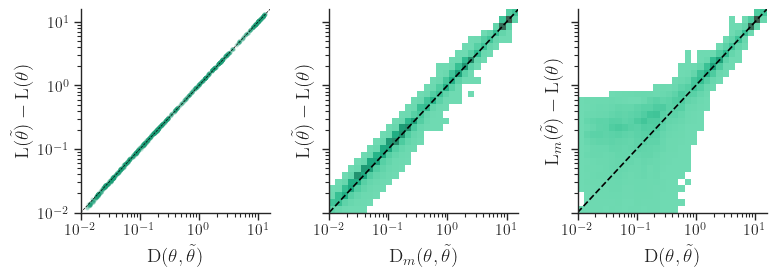

In [25]:
bins = torch.linspace(-2, 1.2, 31)
xs = [10**bins.min(), 10**bins.max()]
_, (ax0, ax1, ax2) = plt.subplots(ncols=3, sharex=False, sharey=False)

kl_div_mean_label = r"$\mathrm{D}(\theta,\tilde{\theta})$"
kl_div_sample_label = r"$\mathrm{D}_m(\theta,\tilde{\theta})$"
cross_entropy_delta_mean_label = r"$\mathrm{L}(\tilde{\theta}) - \mathrm{L}(\theta)$"
cross_entropy_delta_sample_label = r"$\mathrm{L}_m(\tilde{\theta}) - \mathrm{L}(\theta)$"

sns.scatterplot(data=df.sample(1000, random_state=np.random.default_rng(10)), x="kl_div_mean", y="cross_entropy_delta_mean",
                lw=0, alpha=.25, ax=ax0)
ax0.plot(xs, xs, "k--", lw=0.5)
ax0.set_xscale("log")
ax0.set_yscale("log")
ax0.set_xlabel(kl_div_mean_label)
ax0.set_ylabel(cross_entropy_delta_mean_label)

sns.histplot(data=df[df.metric == "kl_div"], x="sample", y="cross_entropy_delta_mean", log_scale=True,
             bins=(bins, bins), ax=ax1)
ax1.plot(xs, xs, "k--")
ax1.tick_params(labelleft=False)
ax1.set_xlabel(kl_div_sample_label)
ax1.set_ylabel(cross_entropy_delta_mean_label)

sns.histplot(data=df[df.metric == "cross_entropy_delta"], y="sample", x="kl_div_mean", log_scale=True,
             bins=(bins, bins), ax=ax2)
ax2.plot(xs, xs, "k--")
ax2.tick_params(labelleft=False)
ax2.set_xlabel(kl_div_mean_label)
ax2.set_ylabel(cross_entropy_delta_sample_label)

for ax in [ax0, ax1, ax2]:
    ax.set_xlim(xs)
    ax.set_ylim(xs)
    ax.tick_params(which="minor", left=True, bottom=True)
    ax.xaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs=range(2, 10), numticks=100))
    ax.xaxis.set_major_locator(matplotlib.ticker.LogLocator(base=10.0, numticks=100))

plot_utils.tidy(ax0.figure)
plot_utils.save("kl_vs_cross_entropy")